# Physics Informed Neural Network with PyTorch 

### 1. Introduction

Traditional neural networks learn by minimizing errors between predictions and known data. PINNs go a step further: they incorporate the known physics (expressed as differential equations) into the training process. This means that even with very little data, the network can still learn physically meaningful solutions.

In this tutorial, we’ll simulate a simple projectile motion problem: a ball thrown with an initial velocity and angle, moving under uniform gravity. We’ll train a PINN to predict both the horizontal and vertical positions over time, using only a handful of data points and the governing equations of motion.

## 2. What Are PINNs?

Imagine you want to predict the trajectory of a cannonball. You already know Newton’s laws: horizontal velocity stays constant, and vertical acceleration is constant (gravity). Instead of collecting thousands of data points, you can build a neural network that *respects* these laws. That’s the core idea behind PINNs.

A PINN is a standard feedforward neural network, but its loss function includes **physics-based terms**. The network learns to satisfy both the observed data and the underlying differential equations.

## 3. Why Use PINNs?

- **Better Predictions with Less Data**: When data is scarce or noisy, the physics guides the network toward the correct solution.
- **Improved Generalization**: Forcing the network to obey physical laws reduces overfitting.
- **Interpretability**: The model’s behaviour is tied to known equations, making it easier to trust and debug.
- **Flexibility**: PINNs can handle complex geometries, inverse problems, and multi‑physics scenarios.

## 4. Use case : Solving the projectile motion

Projectile motion is described by two second‑order ordinary differential equations (ODEs):

$$ \frac{d^2x}{dt^2} = 0, \qquad
\frac{d^2y}{dt^2} = g
$$

where $g$ is gravitational acceleration (negative if upward is positive). The horizontal motion has no acceleration, while the vertical motion has constant acceleration $g$.

The true solution (from high‑school physics) is:

$$
x(t) = v_0 \cos(\alpha)\, t, \qquad
y(t) = h_0 + v_0 \sin(\alpha)\, t + \frac{1}{2} g t^2
$$

where $v_0$ is initial speed, $\alpha$ the launch angle, and $h_0$ the initial height.



In [55]:
#!pip install torch matplotlib numpy 

In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np 

from PIL import Image

In [57]:
# Function for converting png plots files to animated gif - taken from this excelent github repository about PINNs
# https://github.com/benmoseley/harmonic-oscillator-pinn

def save_gif_PIL(outfile, files, fps=5, loop=0):
    "Helper function for saving GIFs"
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='GIF', append_images=imgs[1:], save_all=True, duration=int(1000/fps), loop=loop) 

## Define the architecture 

We define a simple feedforward network with one hidden layer of 50 neurons. The input is time 
t, and the output is a vector (x,y). 

The PINN class that inherits the nn.Module. It also contains: 
* Activation function : Tanh()
* Input layer 
* Hidden layers
* Output layer (x,y) 

In [58]:
# Define the neural network architecture for the PINN
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.activation = nn.Tanh()  # Using Tanh for smooth, non-linear activation
        layer_list = []
        for i in range(len(layers) - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
        self.layers = nn.ModuleList(layer_list)

    def forward(self, t):
        # Pass input through all layers with activation (except final layer)
        for i in range(len(self.layers) - 1):
            t = self.activation(self.layers[i](t))
        t = self.layers[-1](t)
        return t

# Create an instance of the network with defined architecture: 1 input, 3 hidden layers with 20 neurons, 2 outputs
layers = [1, 50, 2] # x(t), y(t)
model = PINN(layers)

## Generate Training Data (Analytical Solution)

We use the true physics to generate some sparse data points for training. 
The gravitational constant is set to g=−9.81, initial speed v_0 =8 m/s, launch angle 60∘, and initial height 1.2 m

In [59]:
# Projectile motion data generator - simple school solution of projectile motion.

def projectile_motion_gen(t, g, v_0, h_0, alpha):
    x = v_0 * torch.cos(alpha) * t
    y = h_0 + v_0 * torch.sin(alpha) * t + 0.5 * g * t**2
    return x.view(-1,1), y.view(-1,1)

In [60]:
g = -9.81
v_0 = 8.0
h_0 = 2.2
alpha = torch.Tensor([torch.pi/3]) # pi/3 -> 60 degrees

# time domain
t = torch.linspace(0, 1.5, 100).view(-1,1)

x, y = projectile_motion_gen(t, g, v_0, h_0, alpha)

# Choosing data for NN training
x_data = x[0:40:8]
y_data = y[0:40:8]
t_data = t[0:40:8]

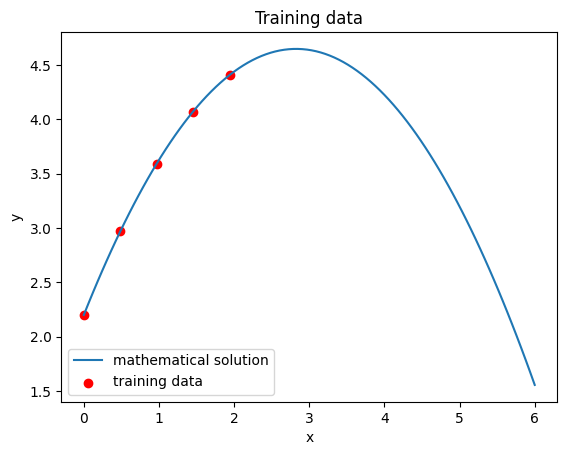

In [61]:
# plot the full analytical trajectory and the training points

plt.figure()
plt.plot(x, y, label='mathematical solution')
plt.scatter(x_data, y_data, color='red', label='training data')
plt.legend()
plt.title('Training data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [62]:
def plots_in_run(t, t_data, x, y, x_h, y_h, x_data, y_data, i, losses_p, losses_d):
    fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
    fig.suptitle(f'Projectile Motion — PINN | step {i + 1:,}', fontweight='bold')

    for ax in axs.flat:
        ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)

    kw = dict(color='gray', lw=1.5), dict(color="#5E4725", s=30, zorder=3), dict(color="#3D9F95", lw=2)

    for ax, (tx, ty) in zip([axs[0,0], axs[1,0]], [('t','x(t)'), ('t','y(t)')]):
        sig = x if ty == 'x(t)' else y
        sig_h = x_h if ty == 'x(t)' else y_h
        sig_d = x_data if ty == 'x(t)' else y_data
        ax.plot(t, sig, **kw[0], label='Analytical')
        ax.scatter(t_data, sig_d, **kw[1], label='Data')
        ax.plot(t, sig_h, **kw[2], label='PINN')
        ax.set(xlabel=tx, ylabel=ty)
        ax.legend(fontsize=9)

    axs[0,1].plot(x, y, **kw[0], label='Analytical')
    axs[0,1].scatter(x_data, y_data, **kw[1], label='Data')
    axs[0,1].plot(x_h, y_h, **kw[2], label='PINN')
    axs[0,1].set(xlabel='x', ylabel='y')
    axs[0,1].legend(fontsize=9)

    axs[1,1].plot(losses_d, color="#2578BD", label=f'Data   ({losses_d[-1]:.2e})')
    axs[1,1].plot(losses_p, color='#EF5350', label=f'Physics ({losses_p[-1]:.2e})')
    axs[1,1].set(xlabel='Iteration', ylabel='Loss')
    axs[1,1].set_yscale('log')
    axs[1,1].legend(fontsize=9)

    return fig

## Define the Physics Loss (PDE Residuals) 

We compute the second derivatives of x and y with respect to time using PyTorch’s automatic differentiation. The residuals should be zero for the true solution.

We use `requires_grad_(True)` to track gradients.

`torch.autograd.grad` computes first and second derivatives.

The physics loss is the mean squared residual.

In [63]:
# Function to compute the PDE residuals for both x and y components of projectile motion: 
# d^2x/dt^2 = 0 and d^2y/dt^2 = g, where g is the gravitational acceleration. 

def loss_physics(model, t):
    # Ensure t has gradients for auto-differentiation
    
    t = t.clone().detach().requires_grad_(True)
    prediction = model(t)
    x = prediction[:,0:1]
    y = prediction[:,1:2]

    # Compute the first derivatives 
    x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    y_t = torch.autograd.grad(y, t, grad_outputs=torch.ones_like(y), create_graph=True)[0]

    # Compute the second derivatives d^2x/dt^2 and d^2y/dt^2
    x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]
    y_tt = torch.autograd.grad(y_t, t, grad_outputs=torch.ones_like(y_t), create_graph=True)[0]
    
    # Calculate the residual of the PDE
    residual_x = x_tt - 0         
    residual_y = y_tt - g    

    loss_x = torch.mean(residual_x**2)
    loss_y = torch.mean(residual_y**2)

    loss_physics = loss_x + loss_y

    return loss_physics

### Define the Initial Condition Loss

At $t=0$, we enforce $x=0$, $y=h_0$, $v_x=v_0*\cos(\alpha)$, $v_y=v_0*\sin(\alpha)$

In [64]:
def initial_condition_loss(model, t0, v0, alpha):
    t0.requires_grad_(True)

    pred = model(t0)
    x = pred[:, 0:1]
    y = pred[:, 1:2]

    x_t = torch.autograd.grad(x, t0, torch.ones_like(x), create_graph=True)[0]
    y_t = torch.autograd.grad(y, t0, torch.ones_like(y), create_graph=True)[0]

    vx0 = v0 * torch.cos(alpha)
    vy0 = v0 * torch.sin(alpha)

    loss_pos = torch.mean(x**2 + y**2)
    loss_vel = torch.mean((x_t - vx0)**2 + (y_t - vy0)**2)

    return loss_pos + loss_vel

## Setting Up Training Components
### Optimizer and Training Parameters

e use the Adam optimizer and train for 6000 epochs. The collocation points (where we enforce the PDE) are 20 equally spaced points between t=0 and t=1.5 

In [65]:
# Set up the optimizer and training parameters
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 6000

# Define collocation points inside the domain for enforcing the PDE residual
t_collocation = torch.linspace(0, 1.5, 20).view(-1, 1)
t0 = torch.zeros((1, 1))

v0 = torch.tensor(6.5)

## Training loop 

During each epoch, we compute the data loss, physics loss, and initial condition loss, then backpropagate. We also store losses for visualisation

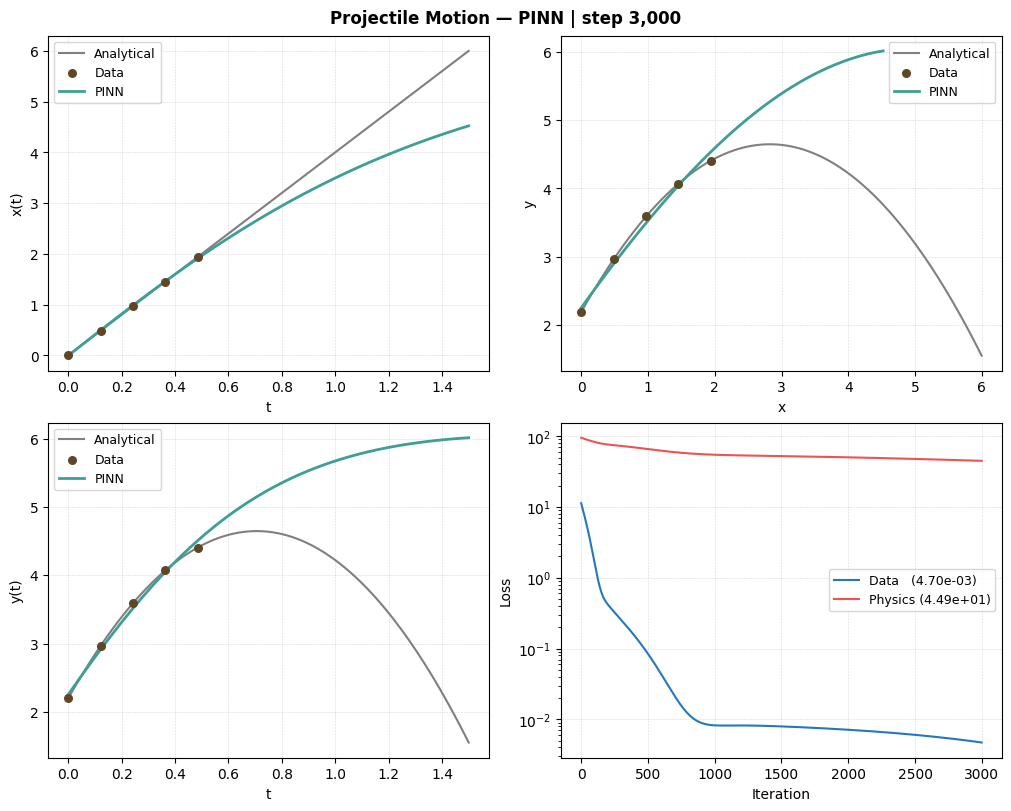

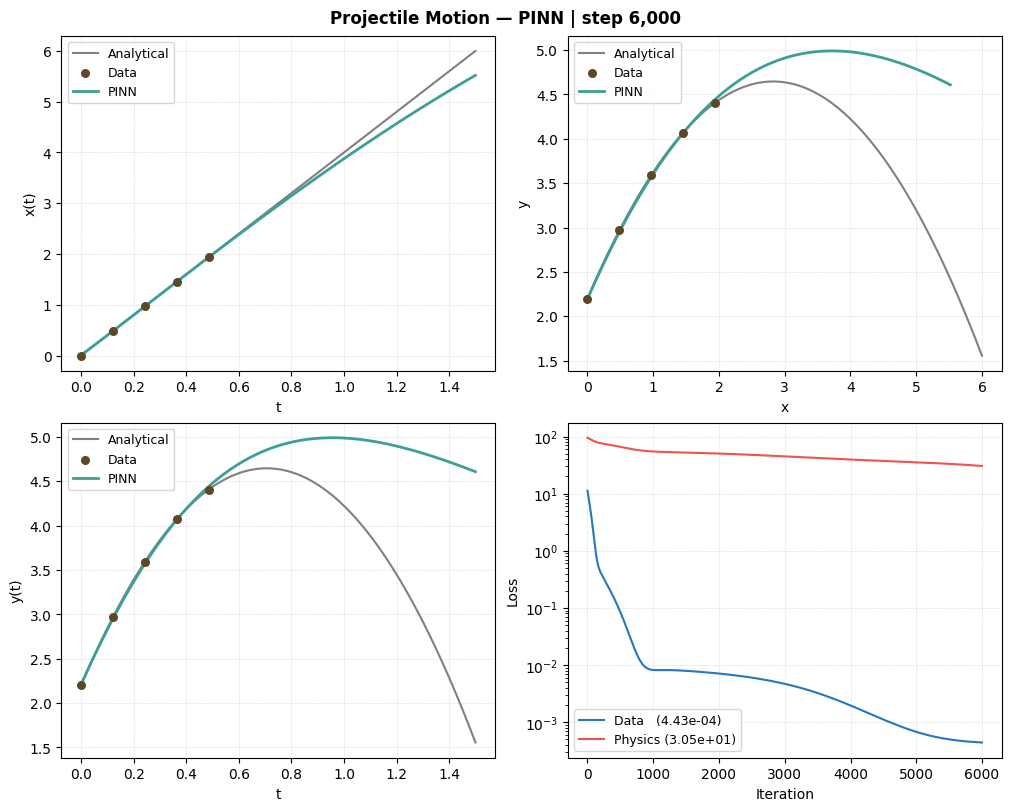

In [66]:
# Neural network initialization
from IPython.display import Image, display

# Training loop
# loss = data MSE + 0.00075 * initial_condition_loss + 0.00075 * loss_physics
print(
    "Loss = mean((x-x_data)^2 + (y-y_data)^2) "
    "+ 0.00075 * initial_condition_loss + 0.00075 * loss_physics"
)
losses_p = []
losses_d = []
files = []
for i in range(num_epochs):
    optimizer.zero_grad()
    
    # forward pass of training data and loss calculation
    prediction = model(t_data)
    x_h, y_h = prediction[:,0:1], prediction[:,1:2]
    loss_1 = torch.mean((x_h - x_data)**2) + torch.mean((y_h - y_data)**2)

    loss_phys = loss_physics(model, t_collocation)
    loss_initial = initial_condition_loss(model, t0, v0, alpha)
    loss = loss_1 + 0.00075 * loss_initial + 0.00075 * loss_phys

    # backpropagation
    loss.backward()
    optimizer.step()

    losses_p.append(loss_phys.item())
    losses_d.append(loss_1.item())

    if (i + 1) % 100 == 0 or i == 0:
        print(
            f"epoch {i + 1}/{num_epochs}  loss={loss.item():.6e}  "
            f"data={loss_1.item():.6e}  physics={loss_phys.item():.6e}  "
            f"initial={loss_initial.item():.6e}"
        )

    # png files generation
    if (i + 1) % 30 == 0:
        z_p = model(t).detach()
        x_h_p, y_h_p = z_p[:,0:1], z_p[:,1:2]
        
        plots_in_run(t, t_data, x, y, x_h_p, y_h_p, x_data, y_data, i, losses_p, losses_d)

        file = "./image/pinn_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)

        if (i + 1) % 1000 == 0: 
            plt.show()
        else: 
            plt.close("all")

# Animated gif generation
save_gif_PIL("./image/pinn.gif", files, fps=20, loop=0)

display(Image(filename="./image/pinn.gif"))

The left plots show x(t)and y(t) over time; the top‑right plot shows the trajectory in the 
xy‑plane. The PINN prediction (blue) closely matches the analytical solution (grey). The bottom‑right plot shows the decreasing losses during training.

# Evaluation 

We test the model on a dense time grid from 0 to 2 seconds and compare with the analytical solution.

In [67]:
model.eval()

with torch.no_grad():
    t_test = torch.linspace(0, 2, 200).view(-1, 1)
    pred = model(t_test)

x_pred = pred[:, 0].numpy()
y_pred = pred[:, 1].numpy()

# Ground truth solution for comparison 
t_np = t_test.numpy()

x_true = v0.numpy() * np.cos(alpha.numpy()) * t_np
y_true = v0.numpy() * np.sin(alpha.numpy()) * t_np - 0.5 * 9.81 * t_np**2

# Calculate Mean Squared Error (MSE) between the predicted and true values
mse_x = np.mean((x_pred - x_true)**2)
mse_y = np.mean((y_pred - y_true)**2)

print("MSE x:", mse_x)
print("MSE y:", mse_y)

MSE x: 7.850243
MSE y: 36.55376


The errors are small, showing that the PINN has successfully learned the correct trajectory.

In [68]:
t_eval = torch.linspace(0, 2, 100).view(-1, 1)

loss_physics = loss_physics(model, t_eval)

print("Residual x (mean abs):", loss_physics.item())

Residual x (mean abs): 46.35028839111328


## Benefits and Limitations
### Benefits

- Physical consistency: The model respects Newton’s laws, even with very few data points.
- Data efficiency: Only 5 data points were used – the physics filled in the gaps.
- Flexibility: The same approach can be extended to more complex ODEs or PDEs.

### Limitations

- Balancing losses: Choosing the right weights for data vs. physics can require tuning.
- Training time: PINNs often need many epochs to converge.
- Scalability: High‑dimensional or stiff equations may be challenging.

## Conclusion
Physics‑Informed Neural Networks offer an elegant way to combine deep learning with physical laws. In this tutorial, we built a PINN that learns projectile motion from just a handful of data points, using the governing ODEs as a guide. The same methodology can be applied to heat transfer, fluid dynamics, structural mechanics, and many other fields.

By incorporating physics into the loss function, PINNs provide accurate, interpretable, and data‑efficient solutions. I encourage you to experiment with the code – try changing the launch angle, adding noise to the data, or even solving a different ODE.


# Ressources 

- Raissi, Maziar, Paris Perdikaris, and George E. Karniadakis. "[Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations](https://www.sciencedirect.com/science/article/pii/S0021999118307125)." Journal of Computational Physics 378 (2019): 686-707.
- 
